# 08 · 與 pandas / numpy 結合：真實資料的視覺化

前面七課都用手刻的小資料。真實工作裡，資料幾乎都裝在 **pandas DataFrame** 或 **numpy 陣列**裡。這課把 matplotlib 接上它們——這也是 matplotlib 入門模組的收尾課。

> 💡 可執行 notebook，`Shift+Enter` 跑每一格。pandas / numpy 在 Colab 都已內建。

## 學習目標

- 用 `df.plot()` 一行畫圖，並理解它**底層就是 matplotlib**
- 把 pandas 的便利與 matplotlib 的控制力**結合**（`df.plot(ax=ax)`）
- `groupby` 彙總後畫圖
- 用 numpy 2D 陣列 + `imshow` / `contourf` 畫**熱圖與等高線**

## 1. pandas 與 matplotlib 的關係

`df.plot()` 不是另一套繪圖系統——它**底層呼叫的就是 matplotlib**，而且**回傳一個 Axes 物件**。所以你可以先用 pandas 快速出圖，再用前幾課學的 `ax.set_xxx()` 繼續客製。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 造一份假的「三家分店每月營收」資料
rng = np.random.default_rng(0)
months = pd.date_range("2025-01", periods=12, freq="MS")
df = pd.DataFrame(
    {
        "Store A": rng.integers(40, 90, 12).cumsum() / 10,
        "Store B": rng.integers(30, 80, 12).cumsum() / 10,
        "Store C": rng.integers(20, 70, 12).cumsum() / 10,
    },
    index=months,
)
df.head()

,Store A,Store B,Store C
2025-01-01,8.2,5.5,3.9
2025-02-01,15.3,11.5,10.1
2025-03-01,21.8,19.3,14.8
2025-04-01,27.1,25.9,16.9
2025-05-01,32.6,32.0,22.7


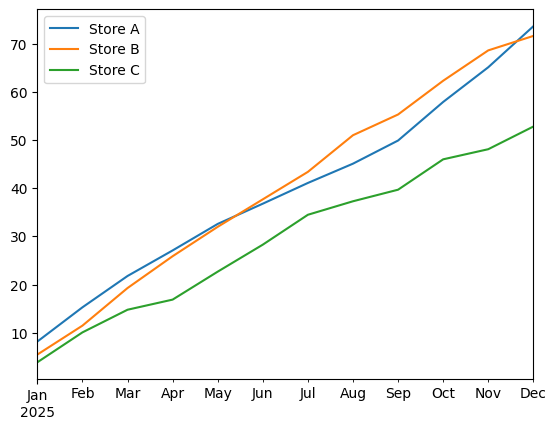

In [2]:
# 一行畫出三條折線——x 軸自動用 DataFrame 的 index（日期）
df.plot()
plt.show()

## 2. 結合：df.plot(ax=ax) 再客製

把自己建的 `ax` 傳進去，pandas 畫完後你接手做細節——這就是兩者結合的關鍵橋樑。

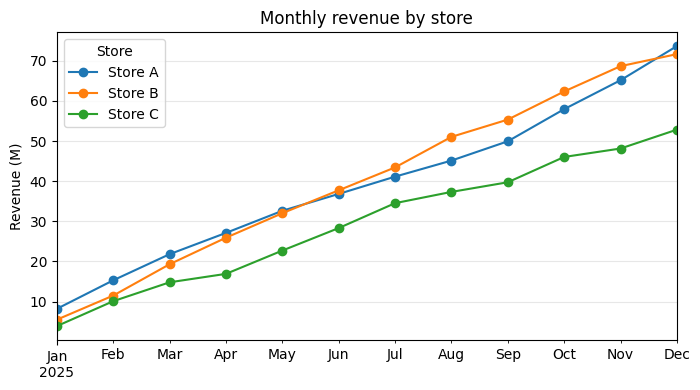

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))

df.plot(ax=ax, marker="o")          # 把 pandas 畫到我指定的 ax 上

# 接手用 matplotlib 的方法客製（前幾課學的東西全都能用）
ax.set_title("Monthly revenue by store")
ax.set_ylabel("Revenue (M)")
ax.grid(True, alpha=0.3)
ax.legend(title="Store")
plt.show()

## 3. groupby 彙總後畫圖

真實資料常是「一列一筆紀錄」，要先 `groupby` 彙總再畫。

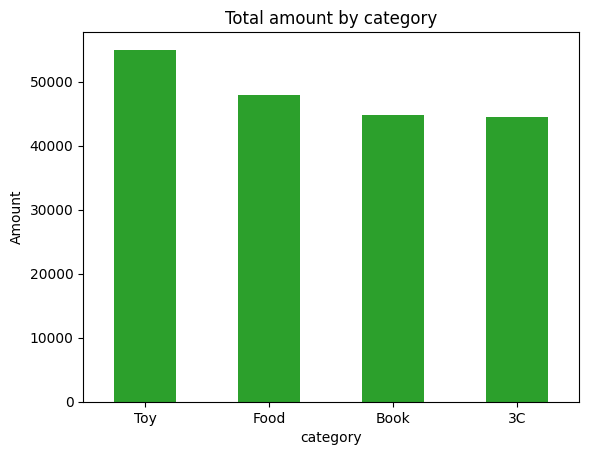

In [4]:
# 假的訂單紀錄：每筆有類別與金額
orders = pd.DataFrame(
    {
        "category": rng.choice(["3C", "Book", "Food", "Toy"], 500),
        "amount": rng.gamma(2.0, 200, 500),
    }
)

# 各類別總金額，由大到小
by_cat = orders.groupby("category")["amount"].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
by_cat.plot.bar(ax=ax, color="tab:green")     # Series 也有 .plot.bar()
ax.set_title("Total amount by category")
ax.set_ylabel("Amount")
ax.tick_params(axis="x", rotation=0)
plt.show()

## 4. numpy 2D：熱圖 imshow

當資料是一個**二維陣列**（影像、相關係數矩陣、地形高度…），用 `imshow` 把數值對應成顏色。配 `colorbar` 當對照尺。

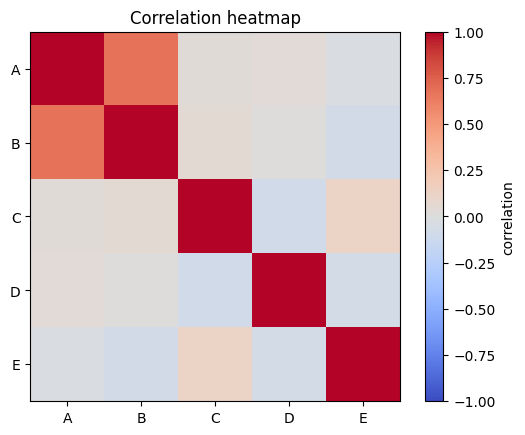

In [5]:
# 相關係數矩陣是最常見的熱圖應用
data = pd.DataFrame(rng.normal(size=(200, 5)), columns=list("ABCDE"))
data["B"] += data["A"]            # 讓 A、B 有相關
corr = data.corr().to_numpy()      # 5x5 numpy 陣列

fig, ax = plt.subplots()
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label="correlation")

labels = list("ABCDE")
ax.set_xticks(range(5), labels)
ax.set_yticks(range(5), labels)
ax.set_title("Correlation heatmap")
plt.show()

## 5. numpy 2D：等高線 contourf

用 `np.meshgrid` 把一維座標展成網格，算出每點的 z 值，再用 `contourf` 畫填色等高線——數學函數、地形、機率密度都常這樣畫。

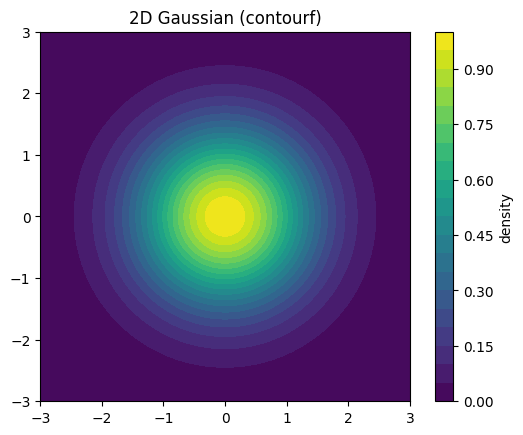

In [6]:
xs = np.linspace(-3, 3, 200)
ys = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(xs, ys)               # 兩個 2D 網格
Z = np.exp(-(X**2 + Y**2) / 2)           # 2D 高斯

fig, ax = plt.subplots()
cs = ax.contourf(X, Y, Z, levels=20, cmap="viridis")
fig.colorbar(cs, ax=ax, label="density")
ax.set_title("2D Gaussian (contourf)")
ax.set_aspect("equal")
plt.show()

## 小結

- `df.plot()` 底層就是 matplotlib、回傳 Axes；先快速出圖，再用 `ax.set_xxx()` 客製。
- 用 `df.plot(ax=ax)` 把 pandas 畫到自己的子圖上——這是兩者結合的橋樑。
- 一列一筆的資料先 `groupby` 彙總再畫。
- 二維陣列用 `imshow`（離散格子，如相關矩陣）或 `contourf`（連續場，配 `meshgrid`）。

## 練習

1. 找一份真實 CSV（`pd.read_csv(...)`），用 `df.plot()` 快速看一眼，再傳 `ax=` 客製標題與軸。
2. 對某個數值 DataFrame 畫相關係數熱圖，並在格子上用 `ax.text()` 標出數值。
3. 把第 5 節的高斯改成兩個高斯相加，看等高線怎麼變。

🎓 **恭喜完成 matplotlib 入門模組！** 從 figure/axes 心智模型，一路到動畫、再到接上真實資料。你已經有完整的視覺化工具箱了——接下來就是拿真實資料多畫、多練。